# Preview YOLO Export

Visualize YOLO segmentation labels as masks overlaid on images.  
Configure the paths and class filter in the **Config** cell below, then run all cells.

In [25]:
import pathlib
import random
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import hsv_to_rgb
from PIL import Image

## Config

In [26]:
YOLO_DIR = pathlib.Path("/home/ruff/fhnw_code/load-simpla-annotations/data/yolo-format")

# Which split to browse: "train", "val", or "test"
SPLIT = ""

# Classes to show — None means all classes
# Example: FILTER_CLASSES = {"PET 0.5l", "Glasflasche"}
FILTER_CLASSES = None #{"BAW-Sack", "Plastiksack"}

# Classes to hide — takes effect after FILTER_CLASSES is applied
# Example: EXCLUDE_CLASSES = {"Container", "Wagon"}
EXCLUDE_CLASSES = None #{"Container", "Wagon"}

# Only show images whose filename contains this substring — None/"" means no filter
# Example: NAME_CONTAINS = "Q3052"
NAME_CONTAINS = "Q3052-151c"

# How many images to display (None = all)
N_IMAGES = 24

# Images per row in the grid
COLS = 2

# Mask opacity (0–1)
ALPHA = 0.7

# Set a seed for reproducible sampling; None for random each run
SEED = 42

In [27]:
# Load class names from the dataset YAML
yaml_path = next(YOLO_DIR.glob("*.yaml"), None) or next(YOLO_DIR.glob("*.yml"))
with open(yaml_path) as f:
    dataset_cfg = yaml.safe_load(f)

class_names: dict[int, str] = {int(k): v for k, v in dataset_cfg["names"].items()}
print(f"Loaded {len(class_names)} classes from {yaml_path.name}:")
for idx, name in class_names.items():
    print(f"  {idx:2d}: {name}")

Loaded 23 classes from data.yml:
   0: Schnur
   1: Container
   2: Zigaretten
   3: Kaffeekapsel
   4: Papier
   5: Katzensand
   6: Plastiksack
   7: Lebensmittelverpackung
   8: Alubuechse
   9: BAW-Sack
  10: Glasflasche
  11: Karton
  12: Alufolie
  13: PET 0.5l
  14: Textilien
  15: Metalle
  16: Windel
  17: PET 1.5l
  18: Styropor/Dämmung
  19: Blumentopf
  20: Diverses
  21: Gummiband
  22: Wagon


In [28]:
def class_color(class_id: int, n_classes: int) -> tuple[float, float, float]:
    """Distinct HSV-derived RGB color per class id using golden-ratio hue stepping."""
    h = (class_id * 0.618033988749895) % 1.0  # golden ratio conjugate — maximally spreads hues
    s = 0.75 + 0.20 * (class_id % 2)           # alternate saturation for extra separation
    return hsv_to_rgb([h, s, 0.95])


def load_labels(label_path: pathlib.Path) -> list[tuple[int, np.ndarray]]:
    """Parse a YOLO segmentation label file.

    Returns list of (class_id, points) where points is Nx2 float array (normalized).
    """
    annotations = []
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 7:  # need at least class + 3 xy pairs
            continue
        class_id = int(parts[0])
        coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
        annotations.append((class_id, coords))
    return annotations


def draw_masks(ax, image: Image.Image, annotations: list, class_filter_ids: set | None):
    """Overlay segmentation polygon masks on ax."""
    w, h = image.size
    ax.imshow(image)
    ax.axis("off")

    n_classes = len(class_names)
    seen_classes = set()

    for class_id, coords in annotations:
        if class_filter_ids is not None and class_id not in class_filter_ids:
            continue

        color = class_color(class_id, n_classes)
        pixel_coords = coords * np.array([w, h])

        poly = plt.Polygon(pixel_coords, closed=True,
                           facecolor=(*color, ALPHA),
                           edgecolor=(*color, 0.9),
                           linewidth=1.0)
        ax.add_patch(poly)
        seen_classes.add(class_id)

    # Legend
    legend_patches = [
        mpatches.Patch(color=class_color(cid, n_classes), label=class_names[cid])
        for cid in sorted(seen_classes)
    ]
    if legend_patches:
        ax.legend(handles=legend_patches, fontsize=6,
                  loc="upper right", framealpha=0.7)

1 of 1 images have visible annotations
Showing 1 images from '' split


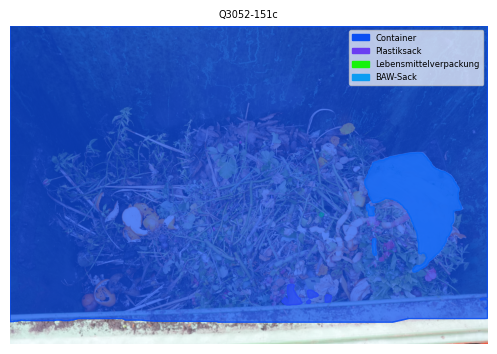

In [29]:
# Resolve class filter to a set of ids
name_to_id = {v: k for k, v in class_names.items()}

if FILTER_CLASSES is not None:
    unknown = FILTER_CLASSES - name_to_id.keys()
    if unknown:
        print(f"Warning: unknown class names in FILTER_CLASSES ignored: {unknown}")
    filter_ids = {name_to_id[n] for n in FILTER_CLASSES if n in name_to_id}
else:
    filter_ids = None

if EXCLUDE_CLASSES:
    unknown = EXCLUDE_CLASSES - name_to_id.keys()
    if unknown:
        print(f"Warning: unknown class names in EXCLUDE_CLASSES ignored: {unknown}")
    exclude_ids = {name_to_id[n] for n in EXCLUDE_CLASSES if n in name_to_id}
    if filter_ids is not None:
        filter_ids -= exclude_ids
    else:
        filter_ids = set(class_names.keys()) - exclude_ids

# Collect image/label pairs for the chosen split
image_dir = YOLO_DIR / "images" / SPLIT
label_dir = YOLO_DIR / "labels" / SPLIT

all_image_paths = sorted(image_dir.glob("*.jpg")) + sorted(image_dir.glob("*.png"))

if NAME_CONTAINS:
    all_image_paths = [p for p in all_image_paths if NAME_CONTAINS in p.name]

# Drop images with no visible annotations after filtering
def has_visible_annotations(img_path: pathlib.Path) -> bool:
    label_path = label_dir / (img_path.stem + ".txt")
    if not label_path.exists():
        return False
    annotations = load_labels(label_path)
    if filter_ids is None:
        return bool(annotations)
    return any(class_id in filter_ids for class_id, _ in annotations)

image_paths = [p for p in all_image_paths if has_visible_annotations(p)]
print(f"{len(image_paths)} of {len(all_image_paths)} images have visible annotations")

rng = random.Random(SEED)
if N_IMAGES is not None and N_IMAGES < len(image_paths):
    image_paths = rng.sample(image_paths, N_IMAGES)

print(f"Showing {len(image_paths)} images from '{SPLIT}' split")

# Draw grid
rows = (len(image_paths) + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 5, rows * 4))
axes = np.array(axes).reshape(-1)  # flatten regardless of shape

for ax, img_path in zip(axes, image_paths):
    label_path = label_dir / (img_path.stem + ".txt")
    image = Image.open(img_path).convert("RGB")
    annotations = load_labels(label_path)
    draw_masks(ax, image, annotations, filter_ids)
    ax.set_title(img_path.stem, fontsize=7)

# Hide unused axes
for ax in axes[len(image_paths):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()